# Module import

In [3]:
import pandas as pd
import numpy as np
import sys, os, random
random.seed(1234)

import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


In [17]:
print(sys.executable)
sys.path.append("/DATA/WGS_study/YSL/projects/latentgee/examples") # sys.path.append()는 파이썬에서 모듈을 임포트할 수 있는 경로를 동적으로 추가할 때
import prototype


def compute_zero_proportion_by_prevalence(otu_df, cutoffs):
    n_samples = otu_df.shape[0]
    proportions = []

    for cutoff in cutoffs:
        # prevalence 계산: 각 OTU의 nonzero 비율
        prevalence = (otu_df > 0).sum(axis=0) / n_samples

        # cutoff 미만인 OTU 제거
        filtered_df = otu_df.loc[:, prevalence >= cutoff]

        # 전체 zero 비율 계산
        zero_count = (filtered_df == 0).sum().sum()
        total_count = filtered_df.size
        zero_proportion = zero_count / total_count

        proportions.append(zero_proportion)

    return proportions



/home/slyang/miniconda3/envs/latentgee/bin/python


In [11]:
import importlib
spec = importlib.util.find_spec("prototype")
print("▶️ spec:", spec)                       # None 이면 경로 문제
print("▶️ origin:", spec.origin if spec else "?")

if spec:
    prototype = importlib.import_module("prototype")
    print("▶️ attrs:", dir(prototype)[:10])    # 함수 포함 여부
    print("▶️ file :", prototype.__file__)

▶️ spec: ModuleSpec(name='prototype', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7bc0b04bc940>, origin='/DATA/WGS_study/YSL/projects/latentgee/examples/prototype.py')
▶️ origin: /DATA/WGS_study/YSL/projects/latentgee/examples/prototype.py
▶️ attrs: ['DataLoader', 'DistanceMatrix', 'Exchangeable', 'F', 'FlexibleMLP', 'FlushFileHandler', 'GEE', 'Gaussian', 'HDBSCAN', 'MDS']
▶️ file : /DATA/WGS_study/YSL/projects/latentgee/examples/prototype.py


In [13]:
def compute_graph_connectivity(mat, batch, k=10, metric="euclidean", algorithm="auto"):
    """
    Parameters
    ----------
    mat   : array-like (n_samples, n_features)
        Expression / embedding matrix.
    batch : array-like (n_samples,)
        Batch label for each sample (str, int… anything hashable).
    k     : int
        Number of nearest neighbours **excluding the query point itself**.
    metric, algorithm : kwargs forwarded to `sklearn.neighbors.NearestNeighbors`.

    Returns
    -------
    dict with
      • per_cell : ndarray, connectivity for each cell  
      • score    : float, mean connectivity ( = graph-connectivity )
    """
    mat   = np.asarray(mat)
    batch = np.asarray(batch)

    if mat.shape[0] != batch.shape[0]:
        raise ValueError("`mat` rows and `batch` length must match")

    # +1 so the first neighbour is the point itself → strip later
    nn = NearestNeighbors(n_neighbors=k + 1, metric=metric, algorithm=algorithm)
    nn.fit(mat)
    distances, indices = nn.kneighbors(mat, return_distance=True)

    # drop the self-edge (column 0)
    neigh_idx   = indices[:, 1:]
    per_cell    = (batch[neigh_idx] == batch[:, None]).mean(axis=1)
    overall     = per_cell.mean()

    return {"per_cell": per_cell, "score": overall}

def kbet_score(
    X,
    batch_labels,
    k: int = 30,
    metric: str = "euclidean",
    algorithm: str = "auto",
    seed: int | None = None,
    return_neighbors: bool = False,
):
    """
    Compute kBET acceptance rate, chi² statistic mean, and p-value mean.

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
    batch_labels : array-like, shape (n_samples,)
    k : int, number of neighbours (excluding self)
    metric, algorithm : kwargs for sklearn NearestNeighbors
    seed : int, random seed for internal sampling
    return_neighbors : bool, also return NeighborsResults object

    Returns
    -------
    accept_rate : float         # ↑ 좋을수록 배치 믹싱 우수
    stat_mean   : float         # kBET χ² 통계량 평균
    pval_mean   : float         # p-value 평균
    nn (opt)    : NeighborsResults
    """
    X = np.asarray(X)
    batch_labels = np.asarray(batch_labels)

    if X.shape[0] != batch_labels.shape[0]:
        raise ValueError("X rows must match length of batch_labels")
    if k >= X.shape[0]:
        raise ValueError("k must be < number of samples")

    if seed is not None:
        np.random.seed(seed)

    nn_search = NearestNeighbors(
        n_neighbors=k + 1, metric=metric, algorithm=algorithm
    ).fit(X)
    dists, idx = nn_search.kneighbors(X)

    nn = NeighborsResults(indices=idx[:, 1:], distances=dists[:, 1:])
    accept_rate, stat_mean, pval_mean = kbet(nn, batches=batch_labels)
    
    # print(f"✔️ kBET acceptance: {accept_rate:.3f}  |  χ²̄: {stat_mean:.2f}  |  p̄: {pval_mean:.2e}")
    
    if return_neighbors:
        return accept_rate, stat_mean, pval_mean, nn
    return accept_rate, stat_mean, pval_mean

# Data load : HIVRC 
'''
hivrc.shape : (38125, 1034)
hivrc_meta.shape : (1032, 5)
'''

In [15]:
# file_path="/Users/linayang/Downloads/slyang/research/Data/Metagenome/externaldata/syn18406854" # macbook
# file_path="/Volumes/Transcend/졸업 후 연구/LatentGEE"# Trascend
# hivrc = pd.read_csv(f"{file_path}/{"Data/insight.merged_otus.txt"}", sep="\t", encoding="utf-8")
# hivrc_meta = pd.read_excel(f"{file_path}/{"Data/SupplementaryMaterial.xlsx"}",
#                            header=1,# 두 번째 행을 컬럼명으로 사용
#                            usecols="B:F"  # 첫 번째 열(A열)은 제외
#                           )
# hivrc_seqid=hivrc_meta["SeqID"].astype(str).to_list()
# hivrc_seqid.insert(0,'Resphera Insight (Raw Counts)')
# hivrc_T=hivrc[hivrc_seqid].T
# hivrc_T.reset_index(inplace=True)
# hivrc_T.columns=hivrc_T.iloc[0].astype(str)
# hivrc_T=hivrc_T.iloc[1:]
# hivrc_T.columns.values[0] = "SeqID"
# hivrc_merged = pd.merge(hivrc_T, hivrc_meta[["SeqID","Study.1","Study"]], on="SeqID", how="inner")
# X_tensor=hivrc_T.iloc[:,1:].apply(pd.to_numeric, errors="coerce")
# X_tensor=torch.tensor(X_tensor.values, dtype=torch.float32)
from pathlib import Path
WORKDIR = "/DATA/WGS_study/YSL/projects/"
DATDIR = "/DATA/WGS_study/YSL/projects/Data"


data_path = Path(f"{DATDIR}/insight.merged_otus.txt")
meta_path = Path(f"{DATDIR}/SupplementaryMaterial.xlsx")

dat = pd.read_csv(data_path, sep="\t", encoding = "utf-8")
dat_meta = pd.read_excel(meta_path, header = 1, usecols = "B:L")

dat_cols = dat_meta["SeqID"].astype(str).to_list()
dat_cols.insert(0, 'Resphera Insight (Raw Counts)')
dat_T = dat[dat_cols].T
dat_T.reset_index(inplace = True)
dat_T.columns = dat_T.iloc[0].astype(str)
dat_T = dat_T.iloc[1:]
dat_T.columns.values[0] = "SeqID"
dat_merged = pd.merge(dat_T, dat_meta, on = "SeqID", how = "inner")

X = dat_merged.iloc[:, 1:(dat_T.shape[1])].apply(pd.to_numeric, errors="coerce").reset_index(drop=True)
dat_cov = dat_merged[['hivstatus', 'Age', 'gender', 'msm','ARTuse', 'cd4']].reset_index(drop=True)

# # prevalence filtering
# prevalence = (X > 0).sum(axis=0) / X.shape[0]
# X = X.loc[:, prevalence > cutoff]

# # relative abundance
# if normalize:
#     X = X.div(X.sum(axis=1), axis=0)
    
assert len(X) == len(dat_cov), f"샘플 수 불일치: X={len(X)}, dat_cov={len(dat_cov)}"


In [ ]:
# print(X.shape)
# print(dat_cov.shape)

,Abiotrophia_defectiva,Acetatifactor_muris:Blautia_coccoides:Blautia_hansenii:Blautia_luti:Blautia_producta:Catonella_morbi:Clostridium_aerotolerans:Clostridium_aldenense:Clostridium_algidixylanolyticum:Clostridium_aminophilum:Clostridium_aminovalericum:Clostridium_amygdalinum:Clostridium_asparagiforme:Clostridium_boliviensis:Clostridium_bolteae:Clostridium_celerecrescens:Clostridium_citroniae:Clostridium_clostridioforme:Clostridium_hathewayi:Clostridium_indolis:Clostridium_lavalense:Clostridium_oroticum:Clostridium_populeti:Clostridium_saccharolyticum:Clostridium_sphenoides:Clostridium_sulfatireducens:Clostridium_symbiosum:Clostridium_xylanolyticum:Dorea_longicatena:Fusicatenibacter_saccharivorans:Hespellia_porcina:Lachnoanaerobaculum_orale:Lachnoanaerobaculum_umeaense:Marvinbryantia_formatexigens:Moryella_indoligenes:Oribacterium_sinus:Robinsoniella_peoriensis:Ruminococcus_gauvreauii:Ruminococcus_lactaris:Stomatobaculum_longum:Syntrophococcus_sucromutans,Acetitomaculum_ruminis,Acetobacter_fabarum:Acetobacter_ghanensis:Acetobacter_pasteurianus:Acetobacter_pomorum:Acetobacter_syzygii,Acetobacterium_carbinolicum:Acetobacterium_fimetarium:Acetobacterium_malicum:Acetobacterium_wieringae,Achromobacter_aegrifaciens:Achromobacter_anxifer:Achromobacter_arsenitoxydans:Achromobacter_denitrificans:Achromobacter_dolens:Achromobacter_insolitus:Achromobacter_insuavis:Achromobacter_marplatensis:Achromobacter_piechaudii:Achromobacter_ruhlandii:Achromobacter_spanius:Achromobacter_xylosoxidans:Bordetella_hinzii:Bordetella_trematum,Achromobacter_aegrifaciens:Achromobacter_anxifer:Achromobacter_denitrificans:Achromobacter_dolens:Achromobacter_insolitus:Achromobacter_insuavis:Achromobacter_marplatensis:Achromobacter_piechaudii:Achromobacter_ruhlandii:Achromobacter_spanius:Achromobacter_xylosoxidans:Bordetella_avium:Bordetella_hinzii:Bordetella_trematum,Achromobacter_aegrifaciens:Achromobacter_anxifer:Achromobacter_denitrificans:Achromobacter_dolens:Achromobacter_insolitus:Achromobacter_insuavis:Achromobacter_marplatensis:Achromobacter_piechaudii:Achromobacter_ruhlandii:Achromobacter_spanius:Achromobacter_xylosoxidans:Bordetella_bronchiseptica:Bordetella_hinzii:Bordetella_parapertussis:Bordetella_petrii:Bordetella_trematum,Achromobacter_aegrifaciens:Achromobacter_anxifer:Achromobacter_denitrificans:Achromobacter_dolens:Achromobacter_insolitus:Achromobacter_insuavis:Achromobacter_marplatensis:Achromobacter_piechaudii:Achromobacter_ruhlandii:Achromobacter_spanius:Achromobacter_xylosoxidans:Bordetella_bronchiseptica:Bordetella_hinzii:Bordetella_parapertussis:Bordetella_petrii:Bordetella_trematum:Kerstersia_gyiorum,Achromobacter_aegrifaciens:Achromobacter_anxifer:Achromobacter_denitrificans:Achromobacter_dolens:Achromobacter_insolitus:Achromobacter_insuavis:Achromobacter_marplatensis:Achromobacter_piechaudii:Achromobacter_ruhlandii:Achromobacter_spanius:Achromobacter_xylosoxidans:Bordetella_hinzii:Bordetella_trematum,...,merged.otu:Yaniella_fodinae,merged.otu:Yersinia_frederiksenii,merged.otu:Yersinia_frederiksenii:Yersinia_massiliensis,merged.otu:Yersinia_massiliensis,merged.otu:Yimella_lutea,merged.otu:Youngiibacter_fragile,merged.otu:Zhihengliuella_salsuginis,merged.otu:Zimmermannella_bifida,merged.otu:Zoogloea_oryzae,merged.otu:Zymophilus_paucivorans
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1027,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1028,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1029,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1030,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Filtering criteria selection - zero proportion by cut-off variation

In [25]:
cutoff_values

array([0.   , 0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 ,
       0.045, 0.05 , 0.055, 0.06 , 0.065, 0.07 , 0.075, 0.08 , 0.085,
       0.09 , 0.095, 0.1  ])

zero prop. of raw data: 99.34%


Text(0, 0.5, 'OTU count')

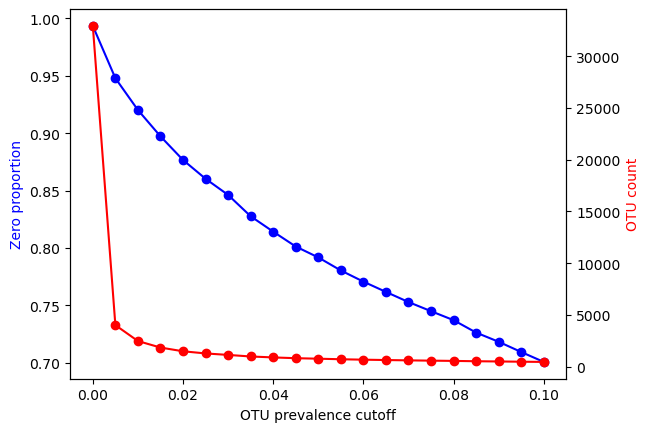

In [ ]:
# otu_df: OTU DataFrame (samples × OTU)
cutoff_values = np.arange(0.00, 0.1005, 0.005)
zero_props = compute_zero_proportion_by_prevalence(X, cutoff_values)
n_otus = []          # OTU 수 추가
zero_prop_total = (X == 0).values.sum() / X.size
zero_prop_df = pd.DataFrame({"Cutoff": cutoff_values,
                             "Prop.":np.round(zero_props, 3)})

# print("zero prop. of raw data:",f"{np.round(zero_prop_total*100,2)}{'%'}")

for cutoff in cutoff_values:
    prevalence = (X > 0).sum(axis=0) / X.shape[0]
    X_filtered = X.loc[:, prevalence > cutoff]
    n_otus.append(X_filtered.shape[1])

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()  # 두 번째 y축

ax1.plot(cutoff_values, zero_props, 'b-o', label='Zero proportion')
ax2.plot(cutoff_values, n_otus, 'r-o', label='OTU count')

ax1.set_xlabel('OTU prevalence cutoff')
ax1.set_ylabel('Zero proportion', color='b')
ax2.set_ylabel('OTU count', color='r')

## Change in Zero Proportion by Prevalence Filter

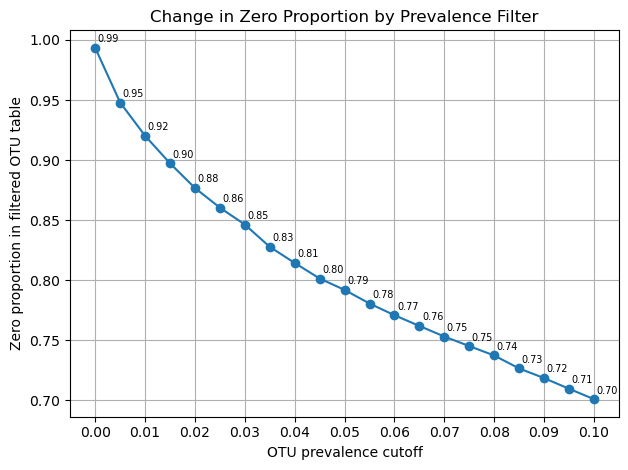

In [213]:
# --- 3. 시각화 ---
file_name="Change in Zero Proportion by Prevalence Filter.png"

plt.plot(cutoff_values, zero_props, marker='o')
plt.xlabel("OTU prevalence cutoff")
plt.ylabel("Zero proportion in filtered OTU table")
plt.title("Change in Zero Proportion by Prevalence Filter")

for x, y  in zip(cutoff_values, zero_props):
    plt.text(x+0.0005, y+0.003, f"{y:.2f}", ha="left", va="bottom", fontsize=7)

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(0.01))
plt.grid(True)
plt.savefig(f"{"./Result"}/{file_name}", dpi=300)
plt.tight_layout()
plt.show() 

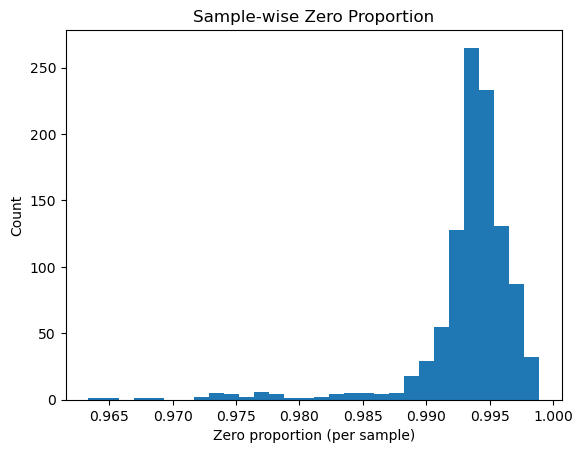

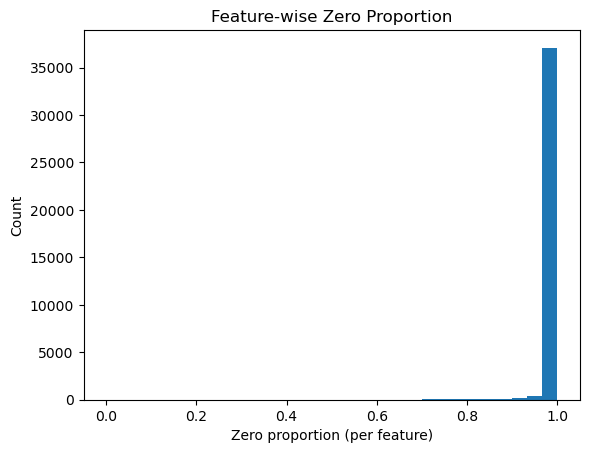

In [21]:
file_name="Sample-wise Zero Proportion"
sample_zero_props = (hivrc_T == 0).mean(axis=1)
plt.hist(sample_zero_props, bins=30)
plt.title(file_name)
plt.xlabel("Zero proportion (per sample)")
plt.ylabel("Count")
plt.savefig(f"{"./Result"}/{"(Raw data)"}{file_name}", dpi=300)
plt.show()

file_name="Feature-wise Zero Proportion"
feature_zero_props = (hivrc_T == 0).mean(axis=0)
plt.hist(feature_zero_props, bins=30)
plt.title("Feature-wise Zero Proportion")
plt.xlabel("Zero proportion (per feature)")
plt.ylabel("Count")
plt.savefig(f"{"./Result"}/{"(Raw data)"}{file_name}", dpi=300)
plt.show()

# Preprocessing
로그 씌우면 안됨.
디코더에 로그노멀우도 쓰임.

최대한 원본분포 보존+비선형패턴 학습

## Scenario 1) min_sample_ratio = 0.1
"""
OTU raw data size: (1032, 38125)
OTU filtering with criteria (1032, 468) 

1. OTU (열) 필터링: 너무 적게 등장한 OTU 제거

샘플이 가진 전체 OTU count 합이 너무 작으면 → 그 샘플은 sequencing depth가 너무 낮거나 noise일 가능성 큼./
열 필터링 기준 : 전체 샘플의 10% 이하 등장 OTU 제거

"""

In [22]:
min_sample_ratio = 0.1

otu_df_scene1=hivrc_T.iloc[:,1:]
otu_df_scene1.index = hivrc_T["SeqID"]
presence = (otu_df_scene1 > 0).sum(axis=0)
otu_df_scene1 = otu_df_scene1.loc[:, presence > (min_sample_ratio * otu_df_scene1.shape[0])]
# print("OTU raw data size:",otu_df_scene1.shape)
print("OTU filtering with criteria",otu_df_scene1.shape,"DONE") # (1032, 468) 


np.save(f"{file_path}/{"Data/hivrc_filtered_scene1.npy"}",otu_df_scene1)
otu_df_scene1.to_pickle(f"{file_path}/{"Data/hivrc_filtered_scene1.pkl"}")
otu_df_scene1.reset_index().to_csv(f"{file_path}/{"Data/hivrc_filtered_scene1.csv"}", index=False)
X_tensor_scene1=otu_df_scene1.apply(pd.to_numeric, errors="coerce")
torch.save(torch.tensor(X_tensor_scene1.values, dtype=torch.float32), 
           f"{file_path}/{"Data/hivrc_tensor_scene1.pt"}")


OTU filtering with criteria (1032, 468) DONE


## Scenario 2) min_sample_ratio = 0.005

In [23]:
min_sample_ratio = 0.005

otu_df_scene2=hivrc_T.iloc[:,1:]
otu_df_scene2.index = hivrc_T["SeqID"]
presence = (otu_df_scene2 > 0).sum(axis=0)
otu_df_scene2 = otu_df_scene2.loc[:, presence > (min_sample_ratio * otu_df_scene2.shape[0])]
print("OTU filtering with criteria",otu_df_scene2.shape,"DONE")

# """ saving codes
np.save(f"{file_path}/{"Data/hivrc_filtered_scene2.npy"}",otu_df_scene2)
otu_df_scene2.to_pickle(f"{file_path}/{"Data/hivrc_filtered_scene2.pkl"}")
otu_df_scene2.reset_index().to_csv(f"{file_path}/{"Data/hivrc_filtered_scene2.csv"}", index=False)
X_tensor_scene2=otu_df_scene2.apply(pd.to_numeric, errors="coerce")
torch.save(torch.tensor(X_tensor_scene2.values, dtype=torch.float32), 
           f"{file_path}/{"Data/hivrc_tensor_scene2.pt"}")
# """

OTU filtering with criteria (1032, 4022) DONE


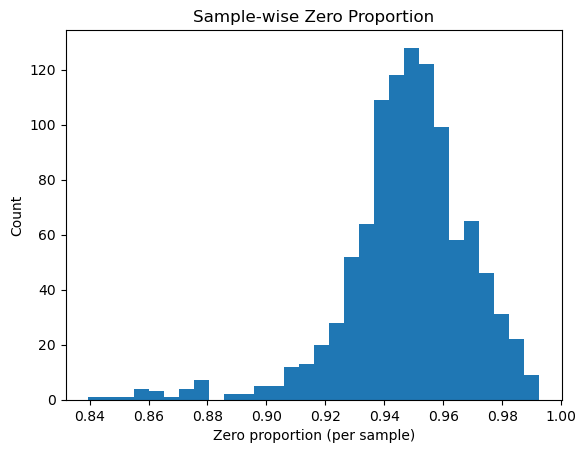

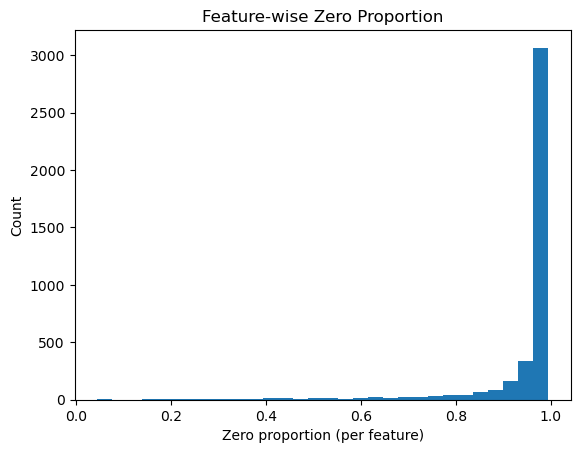

In [ ]:
sample_zero_props = (otu_df_2 == 0).mean(axis=1)
plt.hist(sample_zero_props, bins=30)
plt.title("Sample-wise Zero Proportion")
plt.xlabel("Zero proportion (per sample)")
plt.ylabel("Count")
plt.show()

feature_zero_props = (otu_df_2 == 0).mean(axis=0)
plt.hist(feature_zero_props, bins=30)
plt.title("Feature-wise Zero Proportion")
plt.xlabel("Zero proportion (per feature)")
plt.ylabel("Count")
plt.show()

# Zero-inflation comparison - histogram

## Scenario 1 (zero proportion: 0.70)

In [235]:
print(otu_df_scene1.shape)
print((otu_df_scene1==0).values.sum()/otu_df_scene1.size)

0.7008112204333135


In [ ]:
file_name="Sample-wise Zero Proportion"
sample_zero_props = (otu_df_scene1 == 0).mean(axis=1)
plt.hist(sample_zero_props, bins=30)
plt.title(file_name)
plt.xlabel("Zero proportion (per sample)")
plt.ylabel("Count")
plt.savefig(f"{"./Result"}/{"(Scene1)"}{file_name}", dpi=300)
# plt.show()

In [ ]:
file_name="Feature-wise Zero Proportion"
feature_zero_props = (otu_df_scene1 == 0).mean(axis=0)
plt.hist(feature_zero_props, bins=30)
plt.title("Feature-wise Zero Proportion")
plt.xlabel("Zero proportion (per feature)")
plt.ylabel("Count")
plt.savefig(f"{"./Result"}/{"(Scene1)"}{file_name}", dpi=300)
# plt.show()

## Scenario 2 (zero proportion: 0.95)

In [240]:
print(otu_df_scene2.shape)
print((otu_df_scene2==0).values.sum()/otu_df_scene2.size)

(1032, 4022)
0.9478991997502111


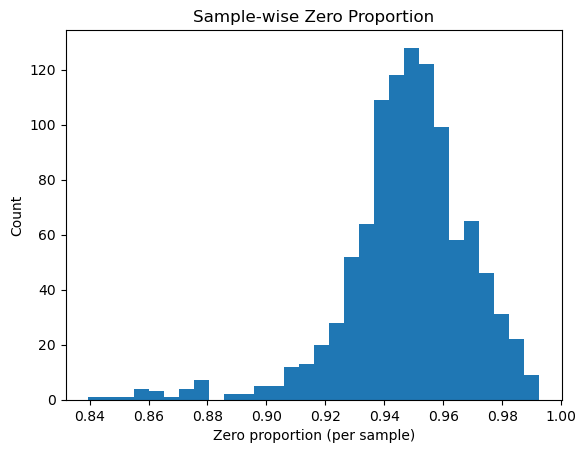

In [241]:
file_name="Sample-wise Zero Proportion"
sample_zero_props = (otu_df_scene2 == 0).mean(axis=1)
plt.hist(sample_zero_props, bins=30)
plt.title(file_name)
plt.xlabel("Zero proportion (per sample)")
plt.ylabel("Count")
plt.savefig(f"{"./Result"}/{"(Scene2)"}{file_name}", dpi=300)
# plt.show()

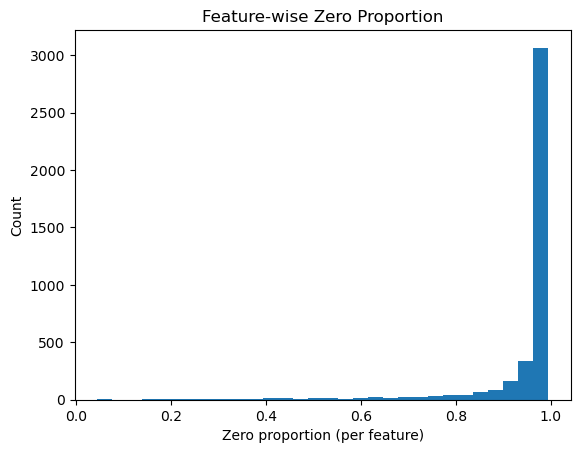

In [242]:
file_name="Feature-wise Zero Proportion"
feature_zero_props = (otu_df_scene2 == 0).mean(axis=0)
plt.hist(feature_zero_props, bins=30)
plt.title("Feature-wise Zero Proportion")
plt.xlabel("Zero proportion (per feature)")
plt.ylabel("Count")
plt.savefig(f"{"./Result"}/{"(Scene2)"}{file_name}", dpi=300)
# plt.show()

# Permanova R-squared

In [24]:
hivrc_merged.index=hivrc_merged["SeqID"]
batch_labels_Raw = np.array(hivrc_merged.loc[hivrc_T["SeqID"], "Study"])

#######################
### Raw data
#######################
perm_bc_res_Raw,perm_bc_r2_Raw  = permanova_r2(hivrc_T.iloc[:,1:],
                                                grouping=batch_labels_Raw,
                                                permutations=999,
                                                metric="braycurtis",
                                                pseudocount=1e-6,)
perm_ait_res_Raw,perm_ait_r2_Raw  = permanova_r2(hivrc_T.iloc[:,1:],
                                                grouping=batch_labels_Raw,
                                                permutations=999,
                                                metric="aitchison",
                                                pseudocount=1e-6,)


#######################
### Scenario 1
#######################
batch_labels_Scene1= np.array(hivrc_merged.loc[otu_df_scene1.index, "Study"])

perm_bc_res_Scene1,perm_bc_r2_Scene1  = permanova_r2(otu_df_scene1,
                                                     grouping=batch_labels_Scene1,
                                                     permutations=999,
                                                     metric="braycurtis",
                                                     pseudocount=1e-6,)
perm_ait_res_Scene1,perm_ait_r2_Scene1  = permanova_r2(otu_df_scene1,
                                                       grouping=batch_labels_Scene1,
                                                       permutations=999,
                                                       metric="aitchison",
                                                       pseudocount=1e-6,)

#######################
### scenario 2
#######################
batch_labels_Scene2= np.array(hivrc_merged.loc[otu_df_scene2.index, "Study"])

perm_bc_res_Scene2,perm_bc_r2_Scene2  = permanova_r2(otu_df_scene2,
                                                     grouping=batch_labels_Scene2,
                                                     permutations=999,
                                                     metric="braycurtis",
                                                     pseudocount=1e-6,)
perm_ait_res_Scene2,perm_ait_r2_Scene2  = permanova_r2(otu_df_scene2,
                                                       grouping=batch_labels_Scene2,
                                                       permutations=999,
                                                       metric="aitchison",
                                                       pseudocount=1e-6,)

/Users/linayang/miniconda3/envs/geezivae_env/lib/python3.13/site-packages/skbio/util/_warning.py:40: DeprecationWarning: `multiplicative_replacement` was renamed to `multi_replace` in 0.6.0. The old name is kept as an alias but is deprecated.
  warn(message, warning)


In [26]:
# print("perm_bc_res_Raw", perm_bc_res_Raw)
print("perm_bc_r2_Raw", perm_bc_r2_Raw.round(4))
print("perm_ait_r2_Raw", perm_ait_r2_Raw.round(4))
print("")


print("perm_bc_r2_Scene1", perm_bc_r2_Scene1.round(4))
print("perm_ait_r2_Scene1", perm_ait_r2_Scene1.round(4))
print("")


print("perm_bc_r2_Scene2", perm_bc_r2_Scene2.round(4))
print("perm_ait_r2_Scene2", perm_ait_r2_Scene2.round(4))
print("")

perm_bc_r2_Raw 0.2965
perm_ait_r2_Raw 0.2625

perm_bc_r2_Scene1 0.3125
perm_ait_r2_Scene1 0.3131

perm_bc_r2_Scene2 0.3003
perm_ait_r2_Scene2 0.2953



# kBET

In [ ]:
k=round(hivrc_T.shape[0]*0.05)
# print(f"✔️ kBET acceptance: {acc:.3f}  |  χ²̄: {chi2:.2f}  |  p̄: {pval:.2e}")

In [ ]:
acc_Raw, chi2_Raw, pval_Raw = kbet_score(hivrc_T.iloc[:,1:], batch_labels_Raw, k=k, metric="braycurtis")

print(acc)
print(len(chi2))
print(len(pval))

0.0
1032
1032


In [80]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from scipy.stats import chi2

def kbet_full(
    X,
    batch_labels,
    k0=None,
    test_size=None,
    n_repeat: int = 100,
    alpha: float = 0.05,
    metric: str = "euclidean",
    algorithm: str = "auto",
    seed: int | None = None,
    proportion: bool = True,
):
    """
    R kBET() 완전 호환 버전:
      • stats$kBET.expected / observed (= n_repeat 길이 벡터)
      • results$expected / observed / pval (= test_size × n_repeat 표)
      • summary: rejection rate, expected, signif (χ²-검정)
    """
    # ---------- 준비 ----------
    if seed is not None:
        rng = np.random.default_rng(seed)
    else:
        rng = np.random.default_rng()
    X = np.asarray(X)
    batch = np.asarray(batch_labels)
    n_cells = X.shape[0]
    if k0 is None:
        k0 = int(np.sqrt(n_cells))
    if k0 >= n_cells:
        raise ValueError("k0 must be < n_cells")
    if test_size is None:
        test_size = max(25, int(0.1 * n_cells))

    # ---------- kNN ----------
    nn = NearestNeighbors(n_neighbors=k0 + 1,
                          metric=metric,
                          algorithm=algorithm).fit(X)
    neigh = nn.kneighbors(X, return_distance=False)[:, 1:]  # (n, k0)

    # ---------- 상수 ----------
    batch_codes, uniq = np.unique(batch, return_inverse=True)
    n_batch = batch_codes.size
    global_prop = np.bincount(uniq) / n_cells
    exp_counts = k0 * global_prop                           # (n_batch,)

    # ---------- 결과 버퍼 ----------
    obs_reject_rate = np.empty(n_repeat)
    exp_reject_rate = np.empty(n_repeat)
    chi2_obs = np.empty(test_size * n_repeat)
    chi2_exp = np.empty_like(chi2_obs)
    p_obs = np.empty_like(chi2_obs)
    p_exp = np.empty_like(chi2_obs)

    # ---------- 반복 ----------
    for r in range(n_repeat):
        sel = rng.choice(n_cells, test_size, replace=False)
        neigh_sel = neigh[sel]                      # (test_size, k0)
        # -- 관측 --
        obs_mat = np.zeros((test_size, n_batch), int)
        for j in range(n_batch):
            obs_mat[:, j] = (uniq[neigh_sel] == j).sum(1)
        chi2_stat = ((obs_mat - exp_counts)**2 / exp_counts).sum(1)
        pvals = chi2.sf(chi2_stat, df=n_batch-1)
        obs_reject_rate[r] = (pvals < alpha).mean()

        # -- 기대 (무작위 레이블링) --
        rand_labels = rng.choice(n_batch, (test_size, k0),
                                 p=global_prop)
        exp_mat = np.zeros_like(obs_mat)
        for j in range(n_batch):
            exp_mat[:, j] = (rand_labels == j).sum(1)
        chi2_rand = ((exp_mat - exp_counts)**2 / exp_counts).sum(1)
        p_rand = chi2.sf(chi2_rand, df=n_batch-1)
        exp_reject_rate[r] = (p_rand < alpha).mean()

        # 버퍼 적재
        base = r * test_size
        chi2_obs[base:base+test_size] = chi2_stat
        chi2_exp[base:base+test_size] = chi2_rand
        p_obs[base:base+test_size] = pvals
        p_exp[base:base+test_size] = p_rand

    # ---------- 비율 변환 ----------
    if proportion:
        obs_mat = obs_mat / k0
        exp_mat = exp_mat / k0

    # ---------- 요약 ----------
    summary = {
        "rejection_rate": obs_reject_rate.mean(),
        "expected_rejection": exp_reject_rate.mean(),
        "p_value": chi2.sf(
            (obs_reject_rate.mean() - exp_reject_rate.mean())**2 /
            exp_reject_rate.var(ddof=1), df=1)
    }

    return {
        "summary": summary,
        "stats": {
            "kBET.expected": exp_reject_rate,
            "kBET.observed": obs_reject_rate
        },
        "results": {
            "observed": obs_mat if proportion else obs_mat * k0,
            "expected": exp_mat if proportion else exp_mat * k0,
            "pval.observed": p_obs.reshape(n_repeat, test_size),
            "pval.expected": p_exp.reshape(n_repeat, test_size)
        },
        "params": {
            "k0": k0, "test_size": test_size, "n_repeat": n_repeat,
            "alpha": alpha, "n_batch": n_batch, "proportion": proportion
        }
    }

In [103]:
kbet_euc_Raw= kbet_full(hivrc_T.iloc[:,1:], batch_labels_Raw, k0=k, seed=1234, n_repeat=500, proportion=True)
kbet_euc_Scene1= kbet_full(otu_df_scene1, batch_labels_Scene1, k0=k, seed=1234, n_repeat=500, proportion=True)
kbet_euc_Scene2= kbet_full(otu_df_scene2, batch_labels_Scene2, k0=k, seed=1234, n_repeat=500, proportion=True)

In [104]:
# R stats$kBET.expected / observed
scenes = [kbet_euc_Raw, kbet_euc_Scene1, kbet_euc_Scene2]

kbet_res_dict = {
    "mean_expected": [np.mean(scene["stats"]["kBET.expected"]) for scene in scenes],
    "mean_observed": [np.mean(scene["stats"]["kBET.observed"]) for scene in scenes]
}


In [105]:
pd.DataFrame(kbet_res_dict, index=["Raw","scene1","scene2"])


,mean_expected,mean_observed
Raw,0.055379,1.0
scene1,0.055379,1.0
scene2,0.055379,1.0


In [112]:
print(hivrc_T.iloc[:,1:].shape)
print(otu_df_scene1.shape)
print(otu_df_scene2.shape)

(1032, 38125)
(1032, 468)
(1032, 4022)


In [110]:
print(kbet_euc_Raw["summary"]["expected_rejection"])
print(kbet_euc_Scene1["summary"]["expected_rejection"])
print(kbet_euc_Scene2["summary"]["expected_rejection"])

0.05537864077669902
0.05537864077669902
0.05537864077669902


array(['Dillon', 'Dillon', 'Dillon', ..., 'Yu', 'Yu', 'Yu'],
      shape=(1032,), dtype=object)